<a href="https://colab.research.google.com/github/OJB-Quantum/Generative-Layout-Notebooks/blob/main/Simple_CPW_Resonator_Coupled_to_Feedline_with_GDSTK_PHIDL_NetworkX_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install phidl gdstk networkx matplotlib numpy

Pylint preflight: SKIP (no script file is available).


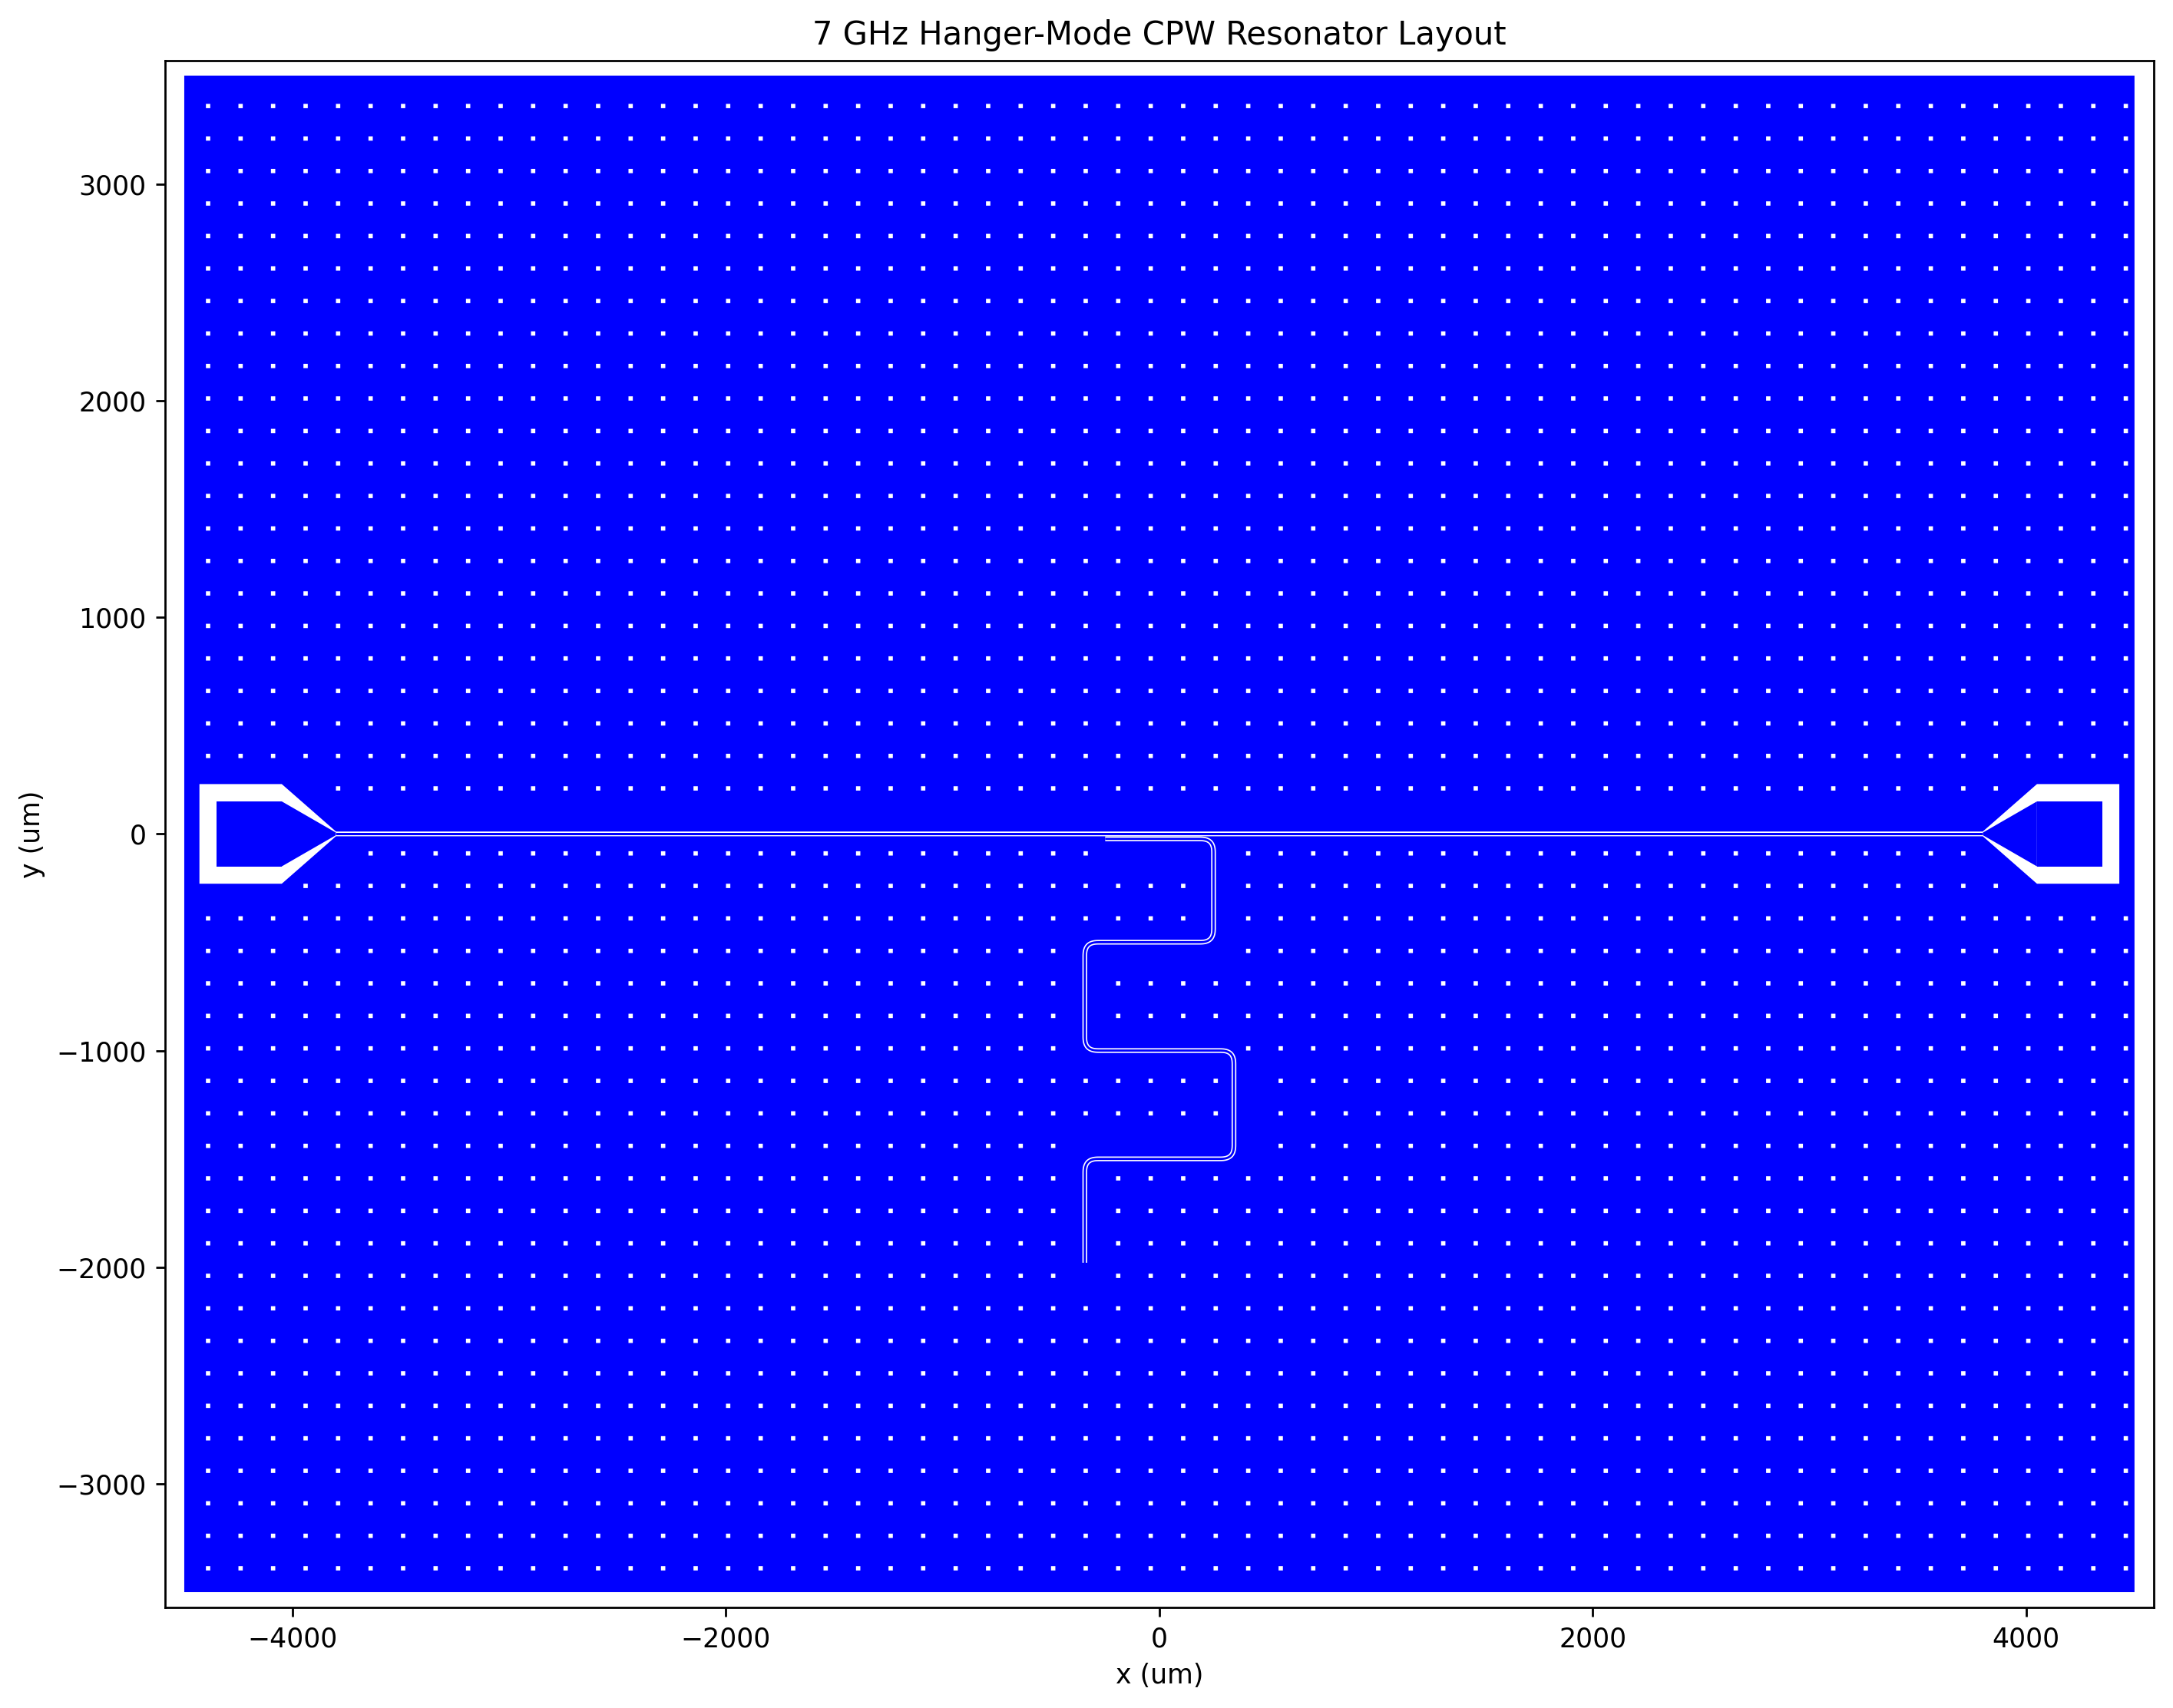

Package versions:
  gdstk: 1.0.1
  phidl: 1.7.2
  networkx: 3.6.1
Effective permittivity: 6.225000
Target quarter-wave length: 4291.340681 um
Realized centerline length: 4291.340561 um
Realized quasi-static frequency: 7.000000196 GHz
Solved meander half width: 344.207 um
Adaptive meander level count: 3
Adaptive meander y levels: -500.000 um, -1000.000 um, -1500.000 um
Resonator tip Euclidean distance from feedline centerline: 2000.000 um
Furthest resonator-metal Euclidean distance from feedline centerline: 2000.000 um
Cheese holes retained: 2645
Flattened polygons: 8
Pre-write vertex-buffer CRC32: 0x3CE022D8
Manual DRC: PASS
OASIS native CRC32: PASS
OASIS written to: /content/hanger_mode_cpw_7ghz.oas
Frequency sizing uses a quasi-static effective-permittivity estimate; final fabrication targeting should be closed with an EM solver.


In [48]:
"""Generate a 7 GHz hanger-mode CPW resonator layout in Google Colab.

The layout uses NetworkX for routing topology, PHIDL for hierarchy and Euler
centerline construction, and GDSTK for polygon generation, boolean ground-plane
processing, in-memory flattening, plotting data extraction, and OASIS export.
The resonator topology automatically re-solves its meander depth and horizontal
amplitude whenever the feedline-to-tip distance control knob is changed.
"""

import importlib.util
import inspect
import math
import os
import pdb
import re
import subprocess
import sys
import zlib
from dataclasses import dataclass, field
from importlib import metadata
from pathlib import Path as FilePath
from typing import Any, Callable, Final, Iterable, Sequence

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import phidl.geometry as pg
import phidl.path as pp
from phidl import Device


# -----------------------------------------------------------------------------
# Control knobs - package/API contract
# -----------------------------------------------------------------------------

MIN_GDSTK_VERSION: Final[str] = "1.0.1"
MIN_PHIDL_VERSION: Final[str] = "1.7.2"
MIN_NETWORKX_VERSION: Final[str] = "3.6.1"
ENABLE_PDB_ON_UNEXPECTED_EXCEPTION: Final[bool] = False
ENABLE_PYLINT_ERROR_PREFLIGHT: Final[bool] = True
PYLINT_MISSING_IS_FATAL: Final[bool] = False


# -----------------------------------------------------------------------------
# Control knobs - output and units
# -----------------------------------------------------------------------------

OUTPUT_OAS_PATH: Final[str] = "/content/hanger_mode_cpw_7ghz.oas"
TOP_CELL_NAME: Final[str] = "HANGER_CPW_7GHZ_TOP"
LIBRARY_NAME: Final[str] = "HANGER_CPW_7GHZ"
LIBRARY_UNIT_M: Final[float] = 1e-6
LIBRARY_PRECISION_M: Final[float] = 1e-9
OAS_COMPRESSION_LEVEL: Final[int] = 6
OAS_VALIDATION: Final[str] = "crc32"


# -----------------------------------------------------------------------------
# Control knobs - coordinate grid and geometry precision
# -----------------------------------------------------------------------------

ENABLE_GRID_SNAPPING: Final[bool] = True
FABRICATION_GRID_UM: Final[float] = 0.001
BOOLEAN_PRECISION_UM: Final[float] = FABRICATION_GRID_UM
PATH_TOLERANCE_UM: Final[float] = 0.005
EULER_POINTS_PER_360: Final[int] = 720


# -----------------------------------------------------------------------------
# Control knobs - chip and layers
# -----------------------------------------------------------------------------

CHIP_WIDTH_UM: Final[float] = 9000.0
CHIP_HEIGHT_UM: Final[float] = 7000.0
CHIP_EDGE_DRC_MARGIN_UM: Final[float] = 50.0
METAL_LAYER: Final[int] = 1
METAL_DATATYPE: Final[int] = 0


# -----------------------------------------------------------------------------
# Control knobs - feedline CPW and launchers
# -----------------------------------------------------------------------------

FEEDLINE_TRACE_WIDTH_UM: Final[float] = 11.7
FEEDLINE_GAP_UM: Final[float] = 5.1
LAUNCHER_PAD_LENGTH_UM: Final[float] = 300.0
LAUNCHER_PAD_WIDTH_UM: Final[float] = 300.0
LAUNCHER_PAD_GAP_UM: Final[float] = 80.0
LAUNCHER_TAPER_LENGTH_UM: Final[float] = 250.0
LAUNCHER_EDGE_INSET_UM: Final[float] = 150.0


# -----------------------------------------------------------------------------
# Control knobs - resonator physics and coupling
# -----------------------------------------------------------------------------

TARGET_RESONATOR_FREQUENCY_HZ: Final[float] = 7.0e9
SUBSTRATE_RELATIVE_PERMITTIVITY: Final[float] = 11.45
EFFECTIVE_PERMITTIVITY_OVERRIDE: Final[float | None] = None
RESONATOR_TRACE_WIDTH_UM: Final[float] = 10.0
RESONATOR_GAP_UM: Final[float] = 6.0
RESONATOR_COUPLING_EDGE_GAP_UM: Final[float] = 12.0
RESONATOR_COUPLER_LENGTH_UM: Final[float] = 500.0
RESONATOR_BEND_RADIUS_UM: Final[float] = 70.0
RESONATOR_EULER_FRACTION: Final[float] = 1.0

# Exact Euclidean distance from the feedline centerline to the furthest
# resonator tip. Default: 3000 micrometers. Changing this knob automatically
# rebuilds the vertical meander levels and re-solves the horizontal amplitude.
FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM: Final[float] = 2000.0

# Automatically reshape the meander after a tip-distance change while preserving
# the quarter-wave target. The preferred topology uses three vertical levels,
# matching the default 750, 1500, and 2250 micrometer depths at a 3000 um tip.
AUTO_ADAPT_RESONATOR_TO_TIP_DISTANCE: Final[bool] = True
PREFERRED_RESONATOR_MEANDER_LEVEL_COUNT: Final[int] = 3
MIN_RESONATOR_MEANDER_LEVEL_COUNT: Final[int] = 1
MAX_RESONATOR_MEANDER_LEVEL_COUNT: Final[int] = 7

# Set this to a positive value to force a fixed horizontal half width. Leave it
# as None to let the geometry solver preserve the 7 GHz quarter-wave length.
RESONATOR_MEANDER_HALF_WIDTH_UM: Final[float | None] = None
RESONATOR_MEANDER_HALF_WIDTH_SEARCH_UM: Final[tuple[float, float]] = (80.0, 1600.0)
RESONATOR_LENGTH_SOLVER_TOLERANCE_UM: Final[float] = 0.001
RESONATOR_LENGTH_DRC_TOLERANCE_UM: Final[float] = 0.05
RESONATOR_FREQUENCY_DRC_TOLERANCE_MHZ: Final[float] = 0.10

SHORT_GROUND_OVERLAP_UM: Final[float] = 20.0
SHORT_BAR_DEPTH_UM: Final[float] = 20.0


# -----------------------------------------------------------------------------
# Control knobs - manual DRC
# -----------------------------------------------------------------------------

MIN_TRACE_WIDTH_UM: Final[float] = 5.0
MIN_GAP_SPACING_UM: Final[float] = 4.0
MIN_TRACE_TO_TRACE_SPACING_UM: Final[float] = 8.0
MIN_BEND_RADIUS_UM: Final[float] = 50.0
GRID_DRC_ATOL_UM: Final[float] = 5e-7


# -----------------------------------------------------------------------------
# Control knobs - ground-plane cheesing and keepouts
# -----------------------------------------------------------------------------

ENABLE_CHEESING: Final[bool] = True
ENABLE_CHEESING_AVOIDANCE: Final[bool] = True
CHEESE_HOLE_SIZE_UM: Final[float] = 20.0
CHEESE_PITCH_UM: Final[float] = 150.0
CHEESE_COMPONENT_KEEPOUT_UM: Final[float] = 55.0
CHEESE_CHIP_EDGE_KEEPOUT_UM: Final[float] = 100.0
CHEESE_GRID_OFFSET_X_UM: Final[float] = 0.0
CHEESE_GRID_OFFSET_Y_UM: Final[float] = 0.0


# -----------------------------------------------------------------------------
# Control knobs - optional junction import
# -----------------------------------------------------------------------------

INCLUDE_JUNCTION_CELL: Final[bool] = False
JUNCTION_GDS_PATH: Final[str | None] = None
JUNCTION_CELL_NAME: Final[str | None] = None
JUNCTION_ORIGIN_UM: Final[tuple[float, float]] = (0.0, -1000.0)


# -----------------------------------------------------------------------------
# Control knobs - in-memory plot
# -----------------------------------------------------------------------------

PLOT_DPI: Final[int] = 250
PLOT_FIGSIZE_IN: Final[tuple[float, float]] = (12.0, 9.0)
PLOT_METAL_COLOR: Final[str] = "#0000FF"
PLOT_LINEWIDTH: Final[float] = 0.0
PLOT_SHOW_AXES: Final[bool] = True


SPEED_OF_LIGHT_M_PER_S: Final[float] = 299_792_458.0


class LayoutContractError(RuntimeError):
    """Raised when a runtime API or package contract is incompatible."""


class DrcViolation(RuntimeError):
    """Raised immediately when the manual layout DRC detects a violation."""


@dataclass(frozen=True)
class LauncherGeometry:
    """Signal and clearance polygons for one CPW launcher."""

    signal: tuple[gdstk.Polygon, ...]
    clearance: tuple[gdstk.Polygon, ...]
    feedline_connection_x: float
    pad_center: tuple[float, float]


@dataclass(frozen=True)
class ResonatorGeometry:
    """Resonator geometry and centerline diagnostics."""

    signal: tuple[gdstk.Polygon, ...]
    clearance: tuple[gdstk.Polygon, ...]
    short_bar: gdstk.Polygon
    centerline: np.ndarray
    phidl_path: Any
    centerline_length_um: float
    meander_half_width_um: float
    meander_level_count: int
    meander_y_levels_um: tuple[float, ...]
    open_end: tuple[float, float]
    tip: tuple[float, float]


@dataclass
class PhidlHierarchyEngine:
    """Manage PHIDL hierarchy, components, and component keepout geometry."""

    top_name: str
    top: Device = field(init=False)
    cells: dict[str, Device] = field(default_factory=dict, init=False)
    keepout_polygons: list[gdstk.Polygon] = field(default_factory=list, init=False)

    def __post_init__(self) -> None:
        self.top = Device(self.top_name)

    def add_component(
        self,
        name: str,
        polygons: Sequence[gdstk.Polygon],
        keepouts: Sequence[gdstk.Polygon] = (),
    ) -> Device:
        """Register one hierarchical PHIDL component from GDSTK polygons."""
        if name in self.cells:
            raise LayoutContractError(f"Duplicate PHIDL cell name: {name}")

        device = Device(name)
        for polygon in polygons:
            device.add_polygon(
                np.asarray(polygon.points, dtype=float),
                layer=(int(polygon.layer), int(polygon.datatype)),
            )
        self.top.add_ref(device)
        self.cells[name] = device
        self.keepout_polygons.extend(keepouts)
        return device

    def maybe_import_junction(self) -> Device | None:
        """Import a junction GDS cell only if the corresponding knob is enabled."""
        if not INCLUDE_JUNCTION_CELL:
            return None
        if not JUNCTION_GDS_PATH:
            raise LayoutContractError(
                "INCLUDE_JUNCTION_CELL is True, but JUNCTION_GDS_PATH is unset."
            )

        imported = safe_kw_call(
            pg.import_gds,
            JUNCTION_GDS_PATH,
            cellname=JUNCTION_CELL_NAME,
            flatten=False,
        )
        reference = self.top.add_ref(imported)
        reference.move(JUNCTION_ORIGIN_UM)
        self.cells[imported.name] = imported
        return imported


@dataclass
class GdstkHierarchyEngine:
    """Manage the final in-memory GDSTK library and cell hierarchy."""

    library_name: str
    top_name: str
    library: gdstk.Library = field(init=False)
    top: gdstk.Cell = field(init=False)
    cells: dict[str, gdstk.Cell] = field(default_factory=dict, init=False)

    def __post_init__(self) -> None:
        self.library = gdstk.Library(
            self.library_name,
            unit=LIBRARY_UNIT_M,
            precision=LIBRARY_PRECISION_M,
        )
        self.top = self.library.new_cell(self.top_name)

    def add_component(
        self,
        name: str,
        polygons: Sequence[gdstk.Polygon],
        origin: tuple[float, float] = (0.0, 0.0),
    ) -> gdstk.Cell:
        """Add one referenced GDSTK component cell to the library."""
        if name in self.cells:
            raise LayoutContractError(f"Duplicate GDSTK cell name: {name}")
        cell = self.library.new_cell(name)
        if polygons:
            cell.add(*polygons)
        self.top.add(gdstk.Reference(cell, origin=origin))
        self.cells[name] = cell
        return cell


def _version_tuple(version: str) -> tuple[int, int, int]:
    """Convert a package version into a three-integer comparison tuple."""
    numbers = [int(value) for value in re.findall(r"\d+", version)[:3]]
    numbers.extend([0] * (3 - len(numbers)))
    return tuple(numbers[:3])


def package_version(distribution_name: str) -> str:
    """Return the installed package version using distribution metadata."""
    try:
        return metadata.version(distribution_name)
    except metadata.PackageNotFoundError as exc:
        raise LayoutContractError(
            f"Required package '{distribution_name}' is not installed."
        ) from exc


def validate_package_versions() -> dict[str, str]:
    """Require the current documented package generation or a newer release."""
    requirements = {
        "gdstk": MIN_GDSTK_VERSION,
        "phidl": MIN_PHIDL_VERSION,
        "networkx": MIN_NETWORKX_VERSION,
    }
    detected: dict[str, str] = {}
    for name, minimum in requirements.items():
        installed = package_version(name)
        detected[name] = installed
        if _version_tuple(installed) < _version_tuple(minimum):
            raise LayoutContractError(
                f"{name} {installed} is older than required {minimum}."
            )
    return detected


def require_attributes(owner: Any, names: Iterable[str], owner_name: str) -> None:
    """Fail early if an expected public API attribute is absent."""
    for name in names:
        if not hasattr(owner, name):
            raise LayoutContractError(
                f"Required API '{owner_name}.{name}' is unavailable."
            )


def validate_keyword_contract(
    function: Callable[..., Any],
    keywords: Iterable[str],
    function_name: str,
) -> None:
    """Check keyword names when Python exposes an inspectable signature."""
    try:
        signature = inspect.signature(function)
    except (TypeError, ValueError):
        return

    parameters = signature.parameters
    if any(
        parameter.kind == inspect.Parameter.VAR_KEYWORD
        for parameter in parameters.values()
    ):
        return

    unsupported = [keyword for keyword in keywords if keyword not in parameters]
    if unsupported:
        joined = ", ".join(unsupported)
        raise LayoutContractError(
            f"{function_name} does not accept expected keyword(s): {joined}."
        )


def safe_kw_call(function: Callable[..., Any], /, *args: Any, **kwargs: Any) -> Any:
    """Call a function after removing unsupported kwargs from inspectable APIs."""
    try:
        signature = inspect.signature(function)
    except (TypeError, ValueError):
        return function(*args, **kwargs)

    parameters = signature.parameters
    accepts_var_kwargs = any(
        parameter.kind == inspect.Parameter.VAR_KEYWORD
        for parameter in parameters.values()
    )
    if accepts_var_kwargs:
        return function(*args, **kwargs)

    filtered = {key: value for key, value in kwargs.items() if key in parameters}
    return function(*args, **filtered)


def validate_runtime_api() -> None:
    """Audit public APIs used by the script before constructing geometry."""
    require_attributes(
        gdstk,
        (
            "Library",
            "Cell",
            "Reference",
            "Polygon",
            "FlexPath",
            "rectangle",
            "boolean",
            "offset",
            "inside",
            "oas_validate",
        ),
        "gdstk",
    )
    require_attributes(pp, ("smooth", "euler"), "phidl.path")
    require_attributes(pg, ("import_gds",), "phidl.geometry")
    require_attributes(Device, ("add_polygon", "add_ref"), "phidl.Device")
    require_attributes(
        nx,
        ("Graph", "is_connected", "shortest_path"),
        "networkx",
    )

    contracts = (
        (
            gdstk.Library.write_oas,
            (
                "compression_level",
                "detect_rectangles",
                "detect_trapezoids",
                "validation",
            ),
            "gdstk.Library.write_oas",
        ),
        (
            gdstk.Cell.get_polygons,
            ("apply_repetitions", "include_paths", "depth"),
            "gdstk.Cell.get_polygons",
        ),
        (
            gdstk.FlexPath,
            (
                "joins",
                "ends",
                "tolerance",
                "simple_path",
                "layer",
                "datatype",
            ),
            "gdstk.FlexPath",
        ),
        (
            gdstk.rectangle,
            ("layer", "datatype"),
            "gdstk.rectangle",
        ),
        (
            gdstk.offset,
            (
                "join",
                "tolerance",
                "precision",
                "use_union",
                "layer",
                "datatype",
            ),
            "gdstk.offset",
        ),
        (
            gdstk.boolean,
            ("precision", "layer", "datatype"),
            "gdstk.boolean",
        ),
        (
            pp.smooth,
            ("points", "radius", "corner_fun", "use_eff"),
            "phidl.path.smooth",
        ),
        (
            pp.euler,
            ("radius", "angle", "p", "use_eff", "num_pts"),
            "phidl.path.euler",
        ),
    )
    for function, keywords, function_name in contracts:
        validate_keyword_contract(function, keywords, function_name)


def run_optional_pylint_preflight() -> None:
    """Run Pylint's error-only checks when Pylint and a source file exist."""
    if not ENABLE_PYLINT_ERROR_PREFLIGHT:
        return

    if importlib.util.find_spec("pylint") is None:
        if PYLINT_MISSING_IS_FATAL:
            raise LayoutContractError(
                "Pylint preflight is enabled, but Pylint is unavailable."
            )
        print("Pylint preflight: SKIP (Pylint is not installed).")
        return

    source_path = globals().get("__file__")
    if not source_path or not os.path.isfile(source_path):
        print("Pylint preflight: SKIP (no script file is available).")
        return

    command = [
        sys.executable,
        "-m",
        "pylint",
        "--errors-only",
        "--extension-pkg-allow-list=gdstk",
        str(source_path),
    ]
    completed = subprocess.run(
        command,
        check=False,
        capture_output=True,
        text=True,
    )
    if completed.returncode != 0:
        diagnostics = (completed.stdout + completed.stderr).strip()
        raise LayoutContractError(
            "Pylint detected an error-class issue before layout generation.\n"
            + diagnostics
        )
    print("Pylint preflight: PASS")


def validate_control_knobs() -> None:
    """Reject inconsistent control-knob combinations before geometry work."""
    positive_values = {
        "FABRICATION_GRID_UM": FABRICATION_GRID_UM,
        "FEEDLINE_TRACE_WIDTH_UM": FEEDLINE_TRACE_WIDTH_UM,
        "FEEDLINE_GAP_UM": FEEDLINE_GAP_UM,
        "RESONATOR_TRACE_WIDTH_UM": RESONATOR_TRACE_WIDTH_UM,
        "RESONATOR_GAP_UM": RESONATOR_GAP_UM,
        "RESONATOR_BEND_RADIUS_UM": RESONATOR_BEND_RADIUS_UM,
        "FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM": (
            FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM
        ),
        "TARGET_RESONATOR_FREQUENCY_HZ": TARGET_RESONATOR_FREQUENCY_HZ,
    }
    for name, value in positive_values.items():
        if value <= 0.0:
            raise LayoutContractError(f"{name} must be positive.")

    if not 0.0 < RESONATOR_EULER_FRACTION <= 1.0:
        raise LayoutContractError(
            "RESONATOR_EULER_FRACTION must lie in the interval (0, 1]."
        )
    if FEEDLINE_GAP_UM < MIN_GAP_SPACING_UM:
        raise DrcViolation(
            "FEEDLINE_GAP_UM is below MIN_GAP_SPACING_UM."
        )
    if RESONATOR_GAP_UM < MIN_GAP_SPACING_UM:
        raise DrcViolation(
            "RESONATOR_GAP_UM is below MIN_GAP_SPACING_UM."
        )
    if FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM >= (
        CHIP_HEIGHT_UM / 2.0 - CHIP_EDGE_DRC_MARGIN_UM
    ):
        raise DrcViolation(
            "The requested feedline-to-tip distance violates the chip-edge "
            "margin."
        )

    if MIN_RESONATOR_MEANDER_LEVEL_COUNT < 1:
        raise LayoutContractError(
            "MIN_RESONATOR_MEANDER_LEVEL_COUNT must be at least 1."
        )
    if MAX_RESONATOR_MEANDER_LEVEL_COUNT < MIN_RESONATOR_MEANDER_LEVEL_COUNT:
        raise LayoutContractError(
            "MAX_RESONATOR_MEANDER_LEVEL_COUNT must be at least the minimum."
        )
    if not (
        MIN_RESONATOR_MEANDER_LEVEL_COUNT
        <= PREFERRED_RESONATOR_MEANDER_LEVEL_COUNT
        <= MAX_RESONATOR_MEANDER_LEVEL_COUNT
    ):
        raise LayoutContractError(
            "PREFERRED_RESONATOR_MEANDER_LEVEL_COUNT must lie inside the "
            "configured automatic level-count range."
        )

    width_low, width_high = RESONATOR_MEANDER_HALF_WIDTH_SEARCH_UM
    if width_low <= 0.0 or width_high <= width_low:
        raise LayoutContractError(
            "RESONATOR_MEANDER_HALF_WIDTH_SEARCH_UM must contain an ordered "
            "positive (low, high) pair."
        )
    maximum_chip_half_width = (
        CHIP_WIDTH_UM / 2.0
        - CHIP_EDGE_DRC_MARGIN_UM
        - RESONATOR_TRACE_WIDTH_UM / 2.0
    )
    if width_high >= maximum_chip_half_width:
        raise DrcViolation(
            "The maximum meander-width search bound reaches the chip-edge "
            "DRC margin."
        )


def install_optional_pdb_hook() -> None:
    """Install a post-mortem debugger hook only when explicitly requested."""
    if not ENABLE_PDB_ON_UNEXPECTED_EXCEPTION:
        return

    original_hook = sys.excepthook

    def _debug_hook(exc_type: type[BaseException], exc: BaseException, tb: Any) -> None:
        original_hook(exc_type, exc, tb)
        pdb.post_mortem(tb)

    sys.excepthook = _debug_hook


def snap_scalar(value: float) -> float:
    """Snap one coordinate or dimension to the fabrication grid."""
    if not ENABLE_GRID_SNAPPING:
        return float(value)
    return round(float(value) / FABRICATION_GRID_UM) * FABRICATION_GRID_UM


def snap_points(points: Sequence[Sequence[float]] | np.ndarray) -> np.ndarray:
    """Snap an array of coordinates to the fabrication grid."""
    array = np.asarray(points, dtype=float)
    if not ENABLE_GRID_SNAPPING:
        return array.copy()
    return np.round(array / FABRICATION_GRID_UM) * FABRICATION_GRID_UM


def snapped_polygon(
    points: Sequence[Sequence[float]] | np.ndarray,
    layer: int = METAL_LAYER,
    datatype: int = METAL_DATATYPE,
) -> gdstk.Polygon:
    """Create a GDSTK polygon from fabrication-grid-snapped coordinates."""
    return gdstk.Polygon(snap_points(points), layer=layer, datatype=datatype)


def snap_polygon_list(polygons: Sequence[gdstk.Polygon]) -> tuple[gdstk.Polygon, ...]:
    """Copy GDSTK polygons onto the fabrication grid."""
    return tuple(
        gdstk.Polygon(
            snap_points(polygon.points),
            layer=int(polygon.layer),
            datatype=int(polygon.datatype),
        )
        for polygon in polygons
    )


def cpw_effective_permittivity() -> float:
    """Return the quasi-static effective permittivity used for initial sizing."""
    if EFFECTIVE_PERMITTIVITY_OVERRIDE is not None:
        return float(EFFECTIVE_PERMITTIVITY_OVERRIDE)
    return 0.5 * (1.0 + SUBSTRATE_RELATIVE_PERMITTIVITY)


def target_quarter_wave_length_um() -> float:
    """Return the target guided quarter wavelength in micrometers."""
    epsilon_eff = cpw_effective_permittivity()
    length_m = SPEED_OF_LIGHT_M_PER_S / (
        4.0 * TARGET_RESONATOR_FREQUENCY_HZ * math.sqrt(epsilon_eff)
    )
    return length_m * 1e6


def frequency_from_length_hz(length_um: float) -> float:
    """Convert a quarter-wave centerline length back into frequency."""
    epsilon_eff = cpw_effective_permittivity()
    length_m = length_um * 1e-6
    return SPEED_OF_LIGHT_M_PER_S / (4.0 * length_m * math.sqrt(epsilon_eff))


def launcher_x_coordinates(side: str) -> tuple[float, float, float]:
    """Return pad outer x, pad inner x, and taper/feedline x for one side."""
    half_chip = CHIP_WIDTH_UM / 2.0
    if side == "left":
        pad_outer = -half_chip + LAUNCHER_EDGE_INSET_UM
        pad_inner = pad_outer + LAUNCHER_PAD_LENGTH_UM
        taper_inner = pad_inner + LAUNCHER_TAPER_LENGTH_UM
        return tuple(map(snap_scalar, (pad_outer, pad_inner, taper_inner)))
    if side == "right":
        pad_outer = half_chip - LAUNCHER_EDGE_INSET_UM
        pad_inner = pad_outer - LAUNCHER_PAD_LENGTH_UM
        taper_inner = pad_inner - LAUNCHER_TAPER_LENGTH_UM
        return tuple(map(snap_scalar, (pad_outer, pad_inner, taper_inner)))
    raise ValueError("side must be 'left' or 'right'")


def build_launcher(side: str) -> LauncherGeometry:
    """Create a square launcher pad, taper, and corresponding CPW clearances."""
    pad_outer_x, pad_inner_x, feed_x = launcher_x_coordinates(side)
    pad_half = LAUNCHER_PAD_WIDTH_UM / 2.0
    feed_half = FEEDLINE_TRACE_WIDTH_UM / 2.0
    gap = LAUNCHER_PAD_GAP_UM
    feed_clear_half = FEEDLINE_TRACE_WIDTH_UM / 2.0 + FEEDLINE_GAP_UM

    if side == "left":
        pad = safe_kw_call(
            gdstk.rectangle,
            (pad_outer_x, -pad_half),
            (pad_inner_x, pad_half),
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        taper_points = (
            (pad_inner_x, -pad_half),
            (feed_x, -feed_half),
            (feed_x, feed_half),
            (pad_inner_x, pad_half),
        )
        pad_clear = safe_kw_call(
            gdstk.rectangle,
            (pad_outer_x - gap, -pad_half - gap),
            (pad_inner_x, pad_half + gap),
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        taper_clear_points = (
            (pad_inner_x, -pad_half - gap),
            (feed_x, -feed_clear_half),
            (feed_x, feed_clear_half),
            (pad_inner_x, pad_half + gap),
        )
    else:
        pad = safe_kw_call(
            gdstk.rectangle,
            (pad_inner_x, -pad_half),
            (pad_outer_x, pad_half),
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        taper_points = (
            (pad_inner_x, -pad_half),
            (feed_x, -feed_half),
            (feed_x, feed_half),
            (pad_inner_x, pad_half),
        )
        pad_clear = safe_kw_call(
            gdstk.rectangle,
            (pad_inner_x, -pad_half - gap),
            (pad_outer_x + gap, pad_half + gap),
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        taper_clear_points = (
            (pad_inner_x, -pad_half - gap),
            (feed_x, -feed_clear_half),
            (feed_x, feed_clear_half),
            (pad_inner_x, pad_half + gap),
        )

    taper = snapped_polygon(taper_points)
    taper_clear = snapped_polygon(taper_clear_points)
    pad_center_x = 0.5 * (pad_outer_x + pad_inner_x)
    return LauncherGeometry(
        signal=snap_polygon_list((pad, taper)),
        clearance=snap_polygon_list((pad_clear, taper_clear)),
        feedline_connection_x=feed_x,
        pad_center=(snap_scalar(pad_center_x), 0.0),
    )


def resonator_open_y() -> float:
    """Return the resonator open-end centerline y coordinate."""
    separation = (
        FEEDLINE_TRACE_WIDTH_UM / 2.0
        + RESONATOR_TRACE_WIDTH_UM / 2.0
        + RESONATOR_COUPLING_EDGE_GAP_UM
    )
    return snap_scalar(-separation)


def resonator_meander_y_levels(level_count: int) -> tuple[float, ...]:
    """Scale meander depths automatically from the requested tip distance."""
    if level_count < 1:
        raise LayoutContractError("Resonator meander level count must be positive.")

    tip_distance = FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM
    fractions = np.arange(1, level_count + 1, dtype=float) / (level_count + 1)
    levels = tuple(snap_scalar(-tip_distance * fraction) for fraction in fractions)

    y_open = resonator_open_y()
    y_tip = snap_scalar(-tip_distance)
    ordered = (y_open, *levels, y_tip)
    separations = np.abs(np.diff(np.asarray(ordered, dtype=float)))
    minimum_vertical_run = 2.0 * RESONATOR_BEND_RADIUS_UM
    if np.any(separations < minimum_vertical_run):
        raise LayoutContractError(
            "The requested tip distance is too short for this meander level "
            "count at the configured Euler bend radius."
        )
    return levels


def resonator_waypoints(
    meander_half_width_um: float,
    level_count: int,
) -> np.ndarray:
    """Create distance-adaptive Manhattan waypoints before Euler smoothing."""
    amplitude = snap_scalar(meander_half_width_um)
    coupler_half = snap_scalar(RESONATOR_COUPLER_LENGTH_UM / 2.0)
    y_open = resonator_open_y()
    y_tip = snap_scalar(-FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM)
    y_levels = resonator_meander_y_levels(level_count)

    points: list[tuple[float, float]] = [
        (-coupler_half, y_open),
        (coupler_half, y_open),
    ]
    current_x = coupler_half
    for index, y_level in enumerate(y_levels):
        points.append((current_x, y_level))
        next_x = -amplitude if index % 2 == 0 else amplitude
        points.append((next_x, y_level))
        current_x = next_x
    points.append((current_x, y_tip))
    return snap_points(points)


def make_smoothed_resonator_path(
    meander_half_width_um: float,
    level_count: int,
) -> Any:
    """Create one PHIDL Euler path for a distance-adaptive meander topology."""
    points = resonator_waypoints(meander_half_width_um, level_count)
    return safe_kw_call(
        pp.smooth,
        points=points,
        radius=RESONATOR_BEND_RADIUS_UM,
        corner_fun=pp.euler,
        use_eff=True,
        p=RESONATOR_EULER_FRACTION,
        num_pts=EULER_POINTS_PER_360,
    )


def smoothed_path_length_um(path: Any) -> float:
    """Measure the snapped PHIDL centerline used by final GDSTK extrusion."""
    points = snap_points(np.asarray(path.points, dtype=float))
    differences = np.diff(points, axis=0)
    return float(np.linalg.norm(differences, axis=1).sum())


def candidate_level_counts() -> tuple[int, ...]:
    """Return automatic topology candidates ordered around the preferred count."""
    available = list(
        range(
            MIN_RESONATOR_MEANDER_LEVEL_COUNT,
            MAX_RESONATOR_MEANDER_LEVEL_COUNT + 1,
        )
    )
    available.sort(
        key=lambda count: (
            abs(count - PREFERRED_RESONATOR_MEANDER_LEVEL_COUNT),
            count,
        )
    )
    return tuple(available)


def meander_half_width_bounds_um() -> tuple[float, float]:
    """Return DRC-aware horizontal half-width bounds for the solver."""
    configured_low, configured_high = RESONATOR_MEANDER_HALF_WIDTH_SEARCH_UM
    spacing_low = 0.5 * (
        RESONATOR_TRACE_WIDTH_UM + MIN_TRACE_TO_TRACE_SPACING_UM
    )
    bend_low = RESONATOR_BEND_RADIUS_UM
    low = snap_scalar(max(configured_low, spacing_low, bend_low))

    chip_limit = (
        CHIP_WIDTH_UM / 2.0
        - CHIP_EDGE_DRC_MARGIN_UM
        - RESONATOR_TRACE_WIDTH_UM / 2.0
    )
    high = snap_scalar(min(configured_high, chip_limit))
    if high <= low:
        raise LayoutContractError(
            "No legal meander half-width interval remains after DRC bounds."
        )
    return low, high


def solve_meander_geometry(target_length_um: float) -> tuple[float, int, Any]:
    """Solve meander topology and half width for tip distance and 7 GHz length."""
    if RESONATOR_MEANDER_HALF_WIDTH_UM is not None:
        amplitude = snap_scalar(RESONATOR_MEANDER_HALF_WIDTH_UM)
        level_count = PREFERRED_RESONATOR_MEANDER_LEVEL_COUNT
        path = make_smoothed_resonator_path(amplitude, level_count)
        return amplitude, level_count, path

    if not AUTO_ADAPT_RESONATOR_TO_TIP_DISTANCE:
        level_count = PREFERRED_RESONATOR_MEANDER_LEVEL_COUNT
        low, high = meander_half_width_bounds_um()
        level_candidates = (level_count,)
    else:
        low, high = meander_half_width_bounds_um()
        level_candidates = candidate_level_counts()

    candidate_brackets: list[tuple[int, float, float]] = []
    rejected: list[str] = []
    for level_count in level_candidates:
        try:
            low_path = make_smoothed_resonator_path(low, level_count)
            high_path = make_smoothed_resonator_path(high, level_count)
        except (LayoutContractError, ValueError) as exc:
            rejected.append(f"levels={level_count}: {exc}")
            continue

        low_length = smoothed_path_length_um(low_path)
        high_length = smoothed_path_length_um(high_path)
        length_min = min(low_length, high_length)
        length_max = max(low_length, high_length)
        if length_min <= target_length_um <= length_max:
            candidate_brackets.append((level_count, low_length, high_length))
        else:
            rejected.append(
                f"levels={level_count}: length bracket "
                f"[{length_min:.3f}, {length_max:.3f}] um"
            )

    if not candidate_brackets:
        detail = "; ".join(rejected)
        raise LayoutContractError(
            "No DRC-compatible adaptive meander topology can satisfy both the "
            f"{FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM:.3f} um tip distance "
            f"and {target_length_um:.3f} um quarter-wave length. {detail}"
        )

    level_count, _, _ = candidate_brackets[0]
    lower = low
    upper = high
    lower_path = make_smoothed_resonator_path(lower, level_count)
    upper_path = make_smoothed_resonator_path(upper, level_count)
    lower_length = smoothed_path_length_um(lower_path)
    upper_length = smoothed_path_length_um(upper_path)
    increasing = upper_length >= lower_length

    best_amplitude = lower
    best_path = lower_path
    for _ in range(100):
        midpoint = 0.5 * (lower + upper)
        candidate_path = make_smoothed_resonator_path(midpoint, level_count)
        candidate_length = smoothed_path_length_um(candidate_path)
        best_amplitude = midpoint
        best_path = candidate_path

        if (
            abs(candidate_length - target_length_um)
            <= RESONATOR_LENGTH_SOLVER_TOLERANCE_UM
        ):
            break
        if increasing:
            if candidate_length < target_length_um:
                lower = midpoint
            else:
                upper = midpoint
        else:
            if candidate_length > target_length_um:
                lower = midpoint
            else:
                upper = midpoint

    snapped_amplitude = snap_scalar(best_amplitude)
    final_path = make_smoothed_resonator_path(snapped_amplitude, level_count)
    return snapped_amplitude, level_count, final_path


def polyline_length(points: np.ndarray) -> float:
    """Return the sampled centerline length of an ordered point array."""
    differences = np.diff(points, axis=0)
    return float(np.linalg.norm(differences, axis=1).sum())


def flexpath_polygons(
    points: np.ndarray,
    width_um: float,
    layer: int = METAL_LAYER,
    datatype: int = METAL_DATATYPE,
) -> tuple[gdstk.Polygon, ...]:
    """Extrude a sampled smooth centerline into snapped GDSTK polygons."""
    flexpath = gdstk.FlexPath(
        points,
        width_um,
        joins="natural",
        ends="flush",
        tolerance=PATH_TOLERANCE_UM,
        simple_path=False,
        layer=layer,
        datatype=datatype,
    )
    return snap_polygon_list(flexpath.to_polygons())


def graph_resonator_waypoints(graph: nx.Graph) -> np.ndarray:
    """Extract resonator waypoints from NetworkX in route-index order."""
    routed_nodes = [
        (int(data["route_index"]), tuple(data["pos"]))
        for _, data in graph.nodes(data=True)
        if data.get("role") == "resonator"
    ]
    if not routed_nodes:
        raise LayoutContractError("Routing graph contains no resonator route nodes.")
    routed_nodes.sort(key=lambda item: item[0])
    return snap_points([point for _, point in routed_nodes])


def build_resonator_from_graph(
    graph: nx.Graph,
    meander_half_width_um: float,
    meander_level_count: int,
) -> ResonatorGeometry:
    """Translate NetworkX resonator nodes into Euler-smoothed GDSTK polygons."""
    waypoints = graph_resonator_waypoints(graph)
    phidl_path = safe_kw_call(
        pp.smooth,
        points=waypoints,
        radius=RESONATOR_BEND_RADIUS_UM,
        corner_fun=pp.euler,
        use_eff=True,
        p=RESONATOR_EULER_FRACTION,
        num_pts=EULER_POINTS_PER_360,
    )
    centerline = snap_points(phidl_path.points)
    centerline[0] = waypoints[0]
    centerline[-1] = waypoints[-1]
    centerline_length = polyline_length(centerline)

    signal = list(flexpath_polygons(centerline, RESONATOR_TRACE_WIDTH_UM))
    clearance_width = RESONATOR_TRACE_WIDTH_UM + 2.0 * RESONATOR_GAP_UM
    clearance = flexpath_polygons(centerline, clearance_width)

    tip_x, tip_y = map(float, centerline[-1])
    short_half_width = clearance_width / 2.0 + SHORT_GROUND_OVERLAP_UM
    short_bar = safe_kw_call(
        gdstk.rectangle,
        (tip_x - short_half_width, tip_y),
        (tip_x + short_half_width, tip_y + SHORT_BAR_DEPTH_UM),
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    short_bar = snap_polygon_list((short_bar,))[0]
    signal.append(short_bar)

    return ResonatorGeometry(
        signal=tuple(signal),
        clearance=clearance,
        short_bar=short_bar,
        centerline=centerline,
        phidl_path=phidl_path,
        centerline_length_um=centerline_length,
        meander_half_width_um=meander_half_width_um,
        meander_level_count=meander_level_count,
        meander_y_levels_um=resonator_meander_y_levels(meander_level_count),
        open_end=tuple(map(float, centerline[0])),
        tip=tuple(map(float, centerline[-1])),
    )


def build_routing_graph(
    left_launcher: LauncherGeometry,
    right_launcher: LauncherGeometry,
    meander_half_width_um: float,
    meander_level_count: int,
) -> nx.Graph:
    """Build the routing graph that drives the CPW topology and geometry."""
    graph = nx.Graph(name="hanger_cpw_routing_graph")

    graph.add_node("left_pad", pos=left_launcher.pad_center, role="launcher")
    graph.add_node(
        "left_taper",
        pos=(left_launcher.feedline_connection_x, 0.0),
        role="taper",
    )
    graph.add_node("feedline_tee", pos=(0.0, 0.0), role="coupling_tee")
    graph.add_node(
        "right_taper",
        pos=(right_launcher.feedline_connection_x, 0.0),
        role="taper",
    )
    graph.add_node("right_pad", pos=right_launcher.pad_center, role="launcher")

    graph.add_edge("left_pad", "left_taper", kind="metal")
    graph.add_edge("left_taper", "feedline_tee", kind="metal")
    graph.add_edge("feedline_tee", "right_taper", kind="metal")
    graph.add_edge("right_taper", "right_pad", kind="metal")

    route_points = resonator_waypoints(
        meander_half_width_um,
        meander_level_count,
    )
    resonator_nodes: list[str] = []
    for index, point in enumerate(route_points):
        node_name = f"res_{index:02d}"
        resonator_nodes.append(node_name)
        graph.add_node(
            node_name,
            pos=tuple(map(float, point)),
            role="resonator",
            route_index=index,
        )
        if index > 0:
            graph.add_edge(resonator_nodes[index - 1], node_name, kind="metal")

    graph.add_node(
        "res_coupler_mid",
        pos=(0.0, resonator_open_y()),
        role="coupled_line_midpoint",
    )
    graph.add_edge("res_00", "res_coupler_mid", kind="route_relation")
    graph.add_edge("res_coupler_mid", "res_01", kind="route_relation")
    graph.add_edge(
        "feedline_tee",
        "res_coupler_mid",
        kind="capacitive_coupling",
        physical_connection=False,
    )
    return graph


def validate_routing_graph(graph: nx.Graph) -> None:
    """Verify graph connectivity and the intended non-galvanic coupling branch."""
    if not nx.is_connected(graph):
        raise LayoutContractError("The routing graph is disconnected.")

    metal_edges = [
        (u, v)
        for u, v, data in graph.edges(data=True)
        if data.get("kind") == "metal"
    ]
    metal_graph = nx.Graph()
    metal_graph.add_nodes_from(graph.nodes(data=True))
    metal_graph.add_edges_from(metal_edges)
    path = nx.shortest_path(metal_graph, "left_pad", "right_pad")
    if "feedline_tee" not in path:
        raise LayoutContractError("Feedline graph does not traverse the tee node.")

    coupling = graph.get_edge_data("feedline_tee", "res_coupler_mid")
    if coupling is None or coupling.get("kind") != "capacitive_coupling":
        raise LayoutContractError(
            "Expected capacitive tee-to-resonator relation is absent."
        )


def build_feedline_from_graph(graph: nx.Graph) -> tuple[gdstk.Polygon, gdstk.Polygon]:
    """Translate the graph feedline endpoints into signal and clearance polygons."""
    left_x = float(graph.nodes["left_taper"]["pos"][0])
    right_x = float(graph.nodes["right_taper"]["pos"][0])
    signal_half = FEEDLINE_TRACE_WIDTH_UM / 2.0
    clear_half = signal_half + FEEDLINE_GAP_UM

    signal = safe_kw_call(
        gdstk.rectangle,
        (left_x, -signal_half),
        (right_x, signal_half),
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    clearance = safe_kw_call(
        gdstk.rectangle,
        (left_x, -clear_half),
        (right_x, clear_half),
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    return snap_polygon_list((signal, clearance))


def polygon_bbox(
    polygons: Sequence[gdstk.Polygon],
) -> tuple[float, float, float, float]:
    """Return a combined polygon bounding box."""
    points = np.vstack(
        [np.asarray(polygon.points, dtype=float) for polygon in polygons]
    )
    return (
        float(points[:, 0].min()),
        float(points[:, 1].min()),
        float(points[:, 0].max()),
        float(points[:, 1].max()),
    )


def generate_cheese_holes(
    component_keepouts: Sequence[gdstk.Polygon],
) -> tuple[gdstk.Polygon, ...]:
    """Generate square ground-plane cheese holes outside expanded keepouts."""
    if not ENABLE_CHEESING:
        return ()

    half_chip_x = CHIP_WIDTH_UM / 2.0
    half_chip_y = CHIP_HEIGHT_UM / 2.0
    half_hole = CHEESE_HOLE_SIZE_UM / 2.0

    x_min = -half_chip_x + CHEESE_CHIP_EDGE_KEEPOUT_UM + half_hole
    x_max = half_chip_x - CHEESE_CHIP_EDGE_KEEPOUT_UM - half_hole
    y_min = -half_chip_y + CHEESE_CHIP_EDGE_KEEPOUT_UM + half_hole
    y_max = half_chip_y - CHEESE_CHIP_EDGE_KEEPOUT_UM - half_hole

    x_values = np.arange(
        x_min + CHEESE_GRID_OFFSET_X_UM,
        x_max + 0.5 * CHEESE_PITCH_UM,
        CHEESE_PITCH_UM,
    )
    y_values = np.arange(
        y_min + CHEESE_GRID_OFFSET_Y_UM,
        y_max + 0.5 * CHEESE_PITCH_UM,
        CHEESE_PITCH_UM,
    )
    centers = np.array([(x, y) for y in y_values for x in x_values], dtype=float)
    centers = snap_points(centers)

    allowed = np.ones(len(centers), dtype=bool)
    if ENABLE_CHEESING_AVOIDANCE and component_keepouts:
        hole_guard = math.sqrt(2.0) * half_hole
        expanded_keepouts = gdstk.offset(
            list(component_keepouts),
            CHEESE_COMPONENT_KEEPOUT_UM + hole_guard,
            join="round",
            tolerance=32,
            precision=BOOLEAN_PRECISION_UM,
            use_union=True,
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        inside_flags = gdstk.inside(centers, expanded_keepouts)
        allowed = np.logical_not(np.asarray(inside_flags, dtype=bool))

    holes: list[gdstk.Polygon] = []
    for x_center, y_center in centers[allowed]:
        hole = safe_kw_call(
            gdstk.rectangle,
            (x_center - half_hole, y_center - half_hole),
            (x_center + half_hole, y_center + half_hole),
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        holes.append(snap_polygon_list((hole,))[0])
    return tuple(holes)


def build_ground_plane(
    clearance_polygons: Sequence[gdstk.Polygon],
    cheese_holes: Sequence[gdstk.Polygon],
) -> tuple[gdstk.Polygon, ...]:
    """Subtract CPW clearances and cheesing from the full-chip ground metal."""
    half_x = CHIP_WIDTH_UM / 2.0
    half_y = CHIP_HEIGHT_UM / 2.0
    chip = safe_kw_call(
        gdstk.rectangle,
        (-half_x, -half_y),
        (half_x, half_y),
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    subtractors = list(clearance_polygons) + list(cheese_holes)
    ground = gdstk.boolean(
        chip,
        subtractors,
        "not",
        precision=BOOLEAN_PRECISION_UM,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    if not ground:
        raise LayoutContractError(
            "Ground-plane boolean operation produced no polygons."
        )
    return snap_polygon_list(ground)


def all_points_on_grid(polygons: Sequence[gdstk.Polygon]) -> bool:
    """Return True if all polygon vertices lie on the fabrication grid."""
    if not ENABLE_GRID_SNAPPING:
        return True
    for polygon in polygons:
        points = np.asarray(polygon.points, dtype=float)
        scaled = points / FABRICATION_GRID_UM
        if not np.allclose(scaled, np.round(scaled), atol=GRID_DRC_ATOL_UM):
            return False
    return True


def polygons_overlap(
    first: Sequence[gdstk.Polygon],
    second: Sequence[gdstk.Polygon],
) -> bool:
    """Return True if two polygon groups have nonzero-area overlap."""
    overlap = gdstk.boolean(
        list(first),
        list(second),
        "and",
        precision=BOOLEAN_PRECISION_UM,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    return bool(overlap)


def point_to_segment_distance_um(
    point: Sequence[float],
    segment_start: Sequence[float],
    segment_end: Sequence[float],
) -> float:
    """Return the Euclidean point-to-segment distance in micrometers."""
    point_array = np.asarray(point, dtype=float)
    start_array = np.asarray(segment_start, dtype=float)
    end_array = np.asarray(segment_end, dtype=float)
    segment = end_array - start_array
    segment_norm_squared = float(np.dot(segment, segment))
    if segment_norm_squared <= 0.0:
        raise LayoutContractError("Feedline centerline segment has zero length.")

    projection = float(
        np.dot(point_array - start_array, segment) / segment_norm_squared
    )
    projection = min(1.0, max(0.0, projection))
    closest_point = start_array + projection * segment
    return float(np.linalg.norm(point_array - closest_point))


def feedline_centerline_segment(
    graph: nx.Graph,
) -> tuple[tuple[float, float], tuple[float, float]]:
    """Return the finite feedline centerline segment represented by the graph."""
    left = tuple(map(float, graph.nodes["left_taper"]["pos"]))
    right = tuple(map(float, graph.nodes["right_taper"]["pos"]))
    return left, right


def feedline_distance_um(point: Sequence[float], graph: nx.Graph) -> float:
    """Return Euclidean distance from a point to the feedline centerline."""
    segment_start, segment_end = feedline_centerline_segment(graph)
    return point_to_segment_distance_um(point, segment_start, segment_end)


def furthest_resonator_metal_distance_um(
    resonator: ResonatorGeometry,
    graph: nx.Graph,
) -> float:
    """Return the largest resonator-metal distance from the feedline centerline."""
    distances = [
        feedline_distance_um(vertex, graph)
        for polygon in resonator.signal
        for vertex in np.asarray(polygon.points, dtype=float)
    ]
    if not distances:
        raise LayoutContractError("Resonator contains no metal vertices.")
    return max(distances)


def manual_drc(
    graph: nx.Graph,
    left_launcher: LauncherGeometry,
    right_launcher: LauncherGeometry,
    feedline_signal: gdstk.Polygon,
    resonator: ResonatorGeometry,
    all_final_polygons: Sequence[gdstk.Polygon],
) -> None:
    """Run Qiskit-Metal-like width, spacing, grid, and boundary checks."""

    def fail(message: str) -> None:
        raise DrcViolation(message)

    if FEEDLINE_TRACE_WIDTH_UM < MIN_TRACE_WIDTH_UM:
        fail("Feedline trace width is below MIN_TRACE_WIDTH_UM.")
    if RESONATOR_TRACE_WIDTH_UM < MIN_TRACE_WIDTH_UM:
        fail("Resonator trace width is below MIN_TRACE_WIDTH_UM.")
    if FEEDLINE_GAP_UM < MIN_GAP_SPACING_UM:
        fail("Feedline CPW gap is below MIN_GAP_SPACING_UM.")
    if RESONATOR_GAP_UM < MIN_GAP_SPACING_UM:
        fail("Resonator CPW gap is below MIN_GAP_SPACING_UM.")
    if RESONATOR_COUPLING_EDGE_GAP_UM < MIN_TRACE_TO_TRACE_SPACING_UM:
        fail("Feedline-to-resonator coupling spacing violates the trace-spacing rule.")
    if RESONATOR_BEND_RADIUS_UM < MIN_BEND_RADIUS_UM:
        fail("Euler bend radius is below MIN_BEND_RADIUS_UM.")

    expected_levels = resonator_meander_y_levels(resonator.meander_level_count)
    if resonator.meander_y_levels_um != expected_levels:
        fail("Stored resonator meander levels differ from the adaptive solution.")

    waypoints = resonator_waypoints(
        resonator.meander_half_width_um,
        resonator.meander_level_count,
    )
    raw_segment_lengths = np.linalg.norm(np.diff(waypoints, axis=0), axis=1)
    if np.any(raw_segment_lengths < 2.0 * RESONATOR_BEND_RADIUS_UM):
        fail("A Manhattan segment is too short to support adjacent Euler bends.")

    feedline_group = (
        *left_launcher.signal,
        feedline_signal,
        *right_launcher.signal,
    )
    inflated_feedline = gdstk.offset(
        list(feedline_group),
        MIN_TRACE_TO_TRACE_SPACING_UM,
        join="round",
        tolerance=32,
        precision=BOOLEAN_PRECISION_UM,
        use_union=True,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    if polygons_overlap(inflated_feedline, resonator.signal):
        fail("Resonator violates minimum trace-to-trace spacing from the feedline.")

    amplitude = resonator.meander_half_width_um
    coupler_half = RESONATOR_COUPLER_LENGTH_UM / 2.0
    x_parallel_clearances = (
        coupler_half + amplitude - RESONATOR_TRACE_WIDTH_UM,
        2.0 * amplitude - RESONATOR_TRACE_WIDTH_UM,
    )
    if min(x_parallel_clearances) < MIN_TRACE_TO_TRACE_SPACING_UM:
        fail("Adjacent resonator meander legs violate trace-to-trace spacing.")

    distance_tolerance = FABRICATION_GRID_UM / 2.0
    tip_distance = feedline_distance_um(resonator.tip, graph)
    if not math.isclose(
        tip_distance,
        FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM,
        rel_tol=0.0,
        abs_tol=distance_tolerance,
    ):
        fail(
            "Resonator tip Euclidean distance from the feedline centerline "
            "is not exactly the requested "
            f"{FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM:.3f} um."
        )

    centerline_distances = [
        feedline_distance_um(point, graph) for point in resonator.centerline
    ]
    furthest_centerline_distance = max(centerline_distances)
    if not math.isclose(
        furthest_centerline_distance,
        FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM,
        rel_tol=0.0,
        abs_tol=distance_tolerance,
    ):
        fail(
            "A resonator centerline point violates the fixed furthest-tip "
            "distance."
        )

    furthest_metal_distance = furthest_resonator_metal_distance_um(
        resonator,
        graph,
    )
    if not math.isclose(
        furthest_metal_distance,
        FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM,
        rel_tol=0.0,
        abs_tol=distance_tolerance,
    ):
        fail(
            "The furthest resonator metal vertex does not land exactly on "
            "the requested feedline-to-tip distance."
        )

    target_length = target_quarter_wave_length_um()
    if (
        abs(resonator.centerline_length_um - target_length)
        > RESONATOR_LENGTH_DRC_TOLERANCE_UM
    ):
        fail("Resonator centerline length misses the quarter-wave target tolerance.")

    realized_frequency = frequency_from_length_hz(resonator.centerline_length_um)
    frequency_error_mhz = abs(realized_frequency - TARGET_RESONATOR_FREQUENCY_HZ) / 1e6
    if frequency_error_mhz > RESONATOR_FREQUENCY_DRC_TOLERANCE_MHZ:
        fail("Realized quasi-static resonator frequency misses the DRC tolerance.")

    if not all_points_on_grid(all_final_polygons):
        fail("One or more final polygon vertices are off the fabrication grid.")

    half_x = CHIP_WIDTH_UM / 2.0
    half_y = CHIP_HEIGHT_UM / 2.0
    signal_polygons = list(feedline_group) + list(resonator.signal)
    x_min, y_min, x_max, y_max = polygon_bbox(signal_polygons)
    if x_min < -half_x + CHIP_EDGE_DRC_MARGIN_UM:
        fail("Signal metal violates the left chip-edge DRC margin.")
    if x_max > half_x - CHIP_EDGE_DRC_MARGIN_UM:
        fail("Signal metal violates the right chip-edge DRC margin.")
    if y_min < -half_y + CHIP_EDGE_DRC_MARGIN_UM:
        fail("Signal metal violates the lower chip-edge DRC margin.")
    if y_max > half_y - CHIP_EDGE_DRC_MARGIN_UM:
        fail("Signal metal violates the upper chip-edge DRC margin.")


def flatten_library_polygons(top_cell: gdstk.Cell) -> tuple[gdstk.Polygon, ...]:
    """Extract flattened polygon copies from the in-memory GDSTK hierarchy."""
    polygons = top_cell.get_polygons(
        apply_repetitions=True,
        include_paths=True,
        depth=None,
    )
    if not polygons:
        raise LayoutContractError("Flattened GDSTK library contains no polygons.")
    return tuple(polygons)


def build_crc_buffer(polygons: Sequence[gdstk.Polygon]) -> bytes:
    """Serialize flattened polygon metadata and vertices into a deterministic buffer."""
    chunks: list[bytes] = [b"HANGER_CPW_VERTEX_BUFFER_V1\0"]
    for polygon in polygons:
        vertices = np.asarray(polygon.points, dtype="<f8", order="C")
        header = np.asarray(
            [int(polygon.layer), int(polygon.datatype), len(vertices)],
            dtype="<i8",
        )
        chunks.append(header.tobytes(order="C"))
        chunks.append(vertices.tobytes(order="C"))
    return b"".join(chunks)


def validate_crc_buffer(buffer: bytes) -> int:
    """Validate the in-memory vertex buffer using independent CRC32 passes."""
    crc_direct = zlib.crc32(buffer) & 0xFFFFFFFF
    crc_incremental = 0
    chunk_size = 64 * 1024
    for start in range(0, len(buffer), chunk_size):
        crc_incremental = zlib.crc32(
            memoryview(buffer)[start : start + chunk_size],
            crc_incremental,
        )
    crc_incremental &= 0xFFFFFFFF
    if crc_direct != crc_incremental:
        raise LayoutContractError("In-memory CRC32 verification failed.")
    return crc_direct


def plot_flattened_polygons(polygons: Sequence[gdstk.Polygon]) -> None:
    """Render the flattened in-memory layout in pure blue without saving an image."""
    mpl.rcParams["figure.dpi"] = PLOT_DPI
    mpl.rcParams["savefig.dpi"] = PLOT_DPI
    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]

    fig, ax = plt.subplots(figsize=PLOT_FIGSIZE_IN, dpi=PLOT_DPI)
    for polygon in polygons:
        vertices = np.asarray(polygon.points, dtype=float)
        ax.fill(
            vertices[:, 0],
            vertices[:, 1],
            facecolor=PLOT_METAL_COLOR,
            edgecolor=PLOT_METAL_COLOR,
            linewidth=PLOT_LINEWIDTH,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.autoscale(enable=True, axis="both", tight=True)
    ax.margins(0.01)
    ax.set_title("7 GHz Hanger-Mode CPW Resonator Layout")
    if PLOT_SHOW_AXES:
        ax.set_xlabel("x (um)")
        ax.set_ylabel("y (um)")
    else:
        ax.set_axis_off()
    fig.tight_layout()
    plt.show()


def write_validated_oas(
    library: gdstk.Library,
    output_path: str,
) -> None:
    """Write an OASIS file with native CRC32 validation and verify the signature."""
    path = FilePath(output_path)
    path.parent.mkdir(parents=True, exist_ok=True)

    safe_kw_call(
        library.write_oas,
        str(path),
        compression_level=OAS_COMPRESSION_LEVEL,
        detect_rectangles=True,
        detect_trapezoids=True,
        validation=OAS_VALIDATION,
    )

    if not gdstk.oas_validate(str(path)):
        raise LayoutContractError("GDSTK OASIS CRC32 signature verification failed.")


def main() -> None:
    """Build, DRC-check, preview, CRC-check, and export the CPW layout."""
    install_optional_pdb_hook()
    run_optional_pylint_preflight()
    versions = validate_package_versions()
    validate_runtime_api()
    validate_control_knobs()

    left_launcher = build_launcher("left")
    right_launcher = build_launcher("right")
    target_length = target_quarter_wave_length_um()
    meander_half_width_um, meander_level_count, _ = solve_meander_geometry(
        target_length
    )
    graph = build_routing_graph(
        left_launcher,
        right_launcher,
        meander_half_width_um,
        meander_level_count,
    )
    validate_routing_graph(graph)
    resonator = build_resonator_from_graph(
        graph,
        meander_half_width_um,
        meander_level_count,
    )
    feedline_signal, feedline_clearance = build_feedline_from_graph(graph)

    component_clearances = (
        *left_launcher.clearance,
        feedline_clearance,
        *right_launcher.clearance,
        *resonator.clearance,
    )
    cheese_keepout_seed = (*component_clearances, resonator.short_bar)
    cheese_holes = generate_cheese_holes(cheese_keepout_seed)
    ground_polygons = build_ground_plane(component_clearances, cheese_holes)

    phidl_engine = PhidlHierarchyEngine(TOP_CELL_NAME + "_PHIDL")
    phidl_engine.add_component(
        "PHIDL_LEFT_LAUNCHER",
        left_launcher.signal,
        left_launcher.clearance,
    )
    phidl_engine.add_component(
        "PHIDL_FEEDLINE",
        (feedline_signal,),
        (feedline_clearance,),
    )
    phidl_engine.add_component(
        "PHIDL_RIGHT_LAUNCHER",
        right_launcher.signal,
        right_launcher.clearance,
    )
    phidl_engine.add_component(
        "PHIDL_RESONATOR",
        resonator.signal,
        resonator.clearance,
    )
    phidl_engine.add_component("PHIDL_GROUND", ground_polygons)
    phidl_engine.maybe_import_junction()

    gdstk_engine = GdstkHierarchyEngine(LIBRARY_NAME, TOP_CELL_NAME)
    gdstk_engine.add_component("LEFT_LAUNCHER", left_launcher.signal)
    gdstk_engine.add_component("FEEDLINE", (feedline_signal,))
    gdstk_engine.add_component("RIGHT_LAUNCHER", right_launcher.signal)
    gdstk_engine.add_component("RESONATOR", resonator.signal)
    gdstk_engine.add_component("GROUND", ground_polygons)

    flattened = flatten_library_polygons(gdstk_engine.top)
    manual_drc(
        graph,
        left_launcher,
        right_launcher,
        feedline_signal,
        resonator,
        flattened,
    )

    vertex_buffer = build_crc_buffer(flattened)
    buffer_crc32 = validate_crc_buffer(vertex_buffer)

    plot_flattened_polygons(flattened)
    write_validated_oas(gdstk_engine.library, OUTPUT_OAS_PATH)

    realized_frequency = frequency_from_length_hz(resonator.centerline_length_um)
    print("Package versions:")
    for name, version in versions.items():
        print(f"  {name}: {version}")
    print(f"Effective permittivity: {cpw_effective_permittivity():.6f}")
    print(f"Target quarter-wave length: {target_quarter_wave_length_um():.6f} um")
    print(f"Realized centerline length: {resonator.centerline_length_um:.6f} um")
    print(f"Realized quasi-static frequency: {realized_frequency / 1e9:.9f} GHz")
    print(f"Solved meander half width: {resonator.meander_half_width_um:.3f} um")
    print(f"Adaptive meander level count: {resonator.meander_level_count}")
    print(
        "Adaptive meander y levels: "
        + ", ".join(f"{value:.3f} um" for value in resonator.meander_y_levels_um)
    )
    tip_distance_um = feedline_distance_um(resonator.tip, graph)
    furthest_metal_distance_um = furthest_resonator_metal_distance_um(
        resonator,
        graph,
    )
    print(
        "Resonator tip Euclidean distance from feedline centerline: "
        f"{tip_distance_um:.3f} um"
    )
    print(
        "Furthest resonator-metal Euclidean distance from feedline centerline: "
        f"{furthest_metal_distance_um:.3f} um"
    )
    print(f"Cheese holes retained: {len(cheese_holes)}")
    print(f"Flattened polygons: {len(flattened)}")
    print(f"Pre-write vertex-buffer CRC32: 0x{buffer_crc32:08X}")
    print("Manual DRC: PASS")
    print("OASIS native CRC32: PASS")
    print(f"OASIS written to: {OUTPUT_OAS_PATH}")
    print(
        "Frequency sizing uses a quasi-static effective-permittivity estimate; "
        "final fabrication targeting should be closed with an EM solver."
    )

if __name__ == "__main__":
    try:
        main()
    except (LayoutContractError, DrcViolation):
        raise
    except Exception:
        if ENABLE_PDB_ON_UNEXPECTED_EXCEPTION:
            pdb.post_mortem()
        raise